In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


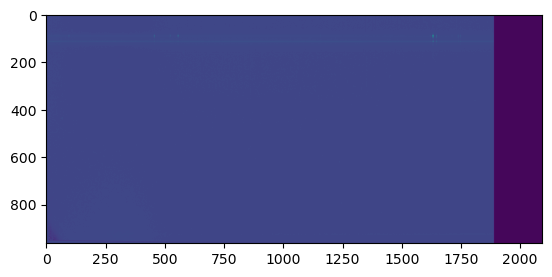

In [4]:
plt.imshow(image)

In [5]:
image_cut = image[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

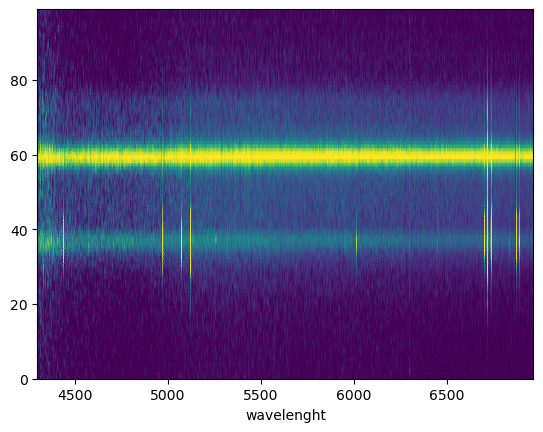

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 0, 'wavelenght')

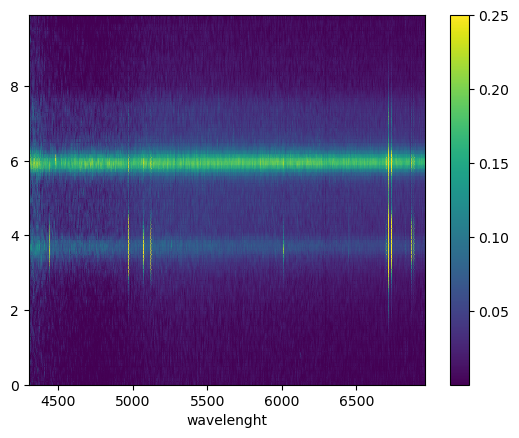

In [7]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
fig = plt.figure()
ax  = fig.add_subplot()
pmesh = ax.pcolormesh(x_grid, 0.1*y_grid, (image_cut), shading='gouraud',cmap='viridis',vmin=0.00000085,vmax=0.25)
cbar = plt.colorbar(pmesh,ax=ax)
plt.xlabel('wavelenght')

We know that redshift and wavelenghts are related in this way:
$\lambda_{obs} = \lambda_{em}*(1+z)$ \\
So if we want:
- $\lambda_{obs}(H\alpha)$ = 6563 * (1+0.0238) = 6719 AA
- $\lambda_{obs}(H\beta)$ = 4861 * (1+0.0238) = 4977 AA
- $\lambda_{obs}([NII])$ = 6548 * (1+0.0238) = 6704 AA
- $\lambda_{obs}([SII])$ = 6717 * (1+0.0238) = 6877 AA
- $\lambda_{obs}([OIII])$ = 4959 * (1+0.0238) = 5077 AA


## Continuum 6500 AA

Text(0.5, 1.0, 'Continuum 6500 A')

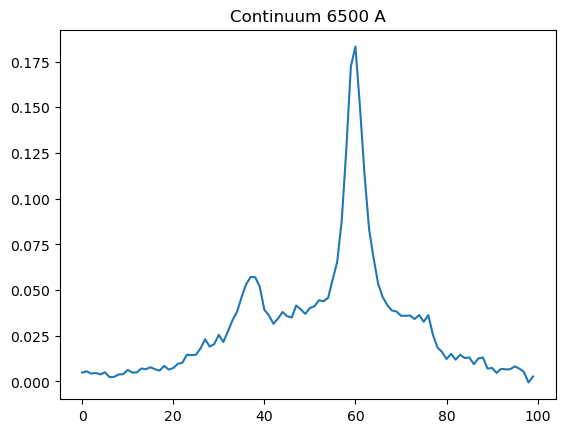

In [8]:
mask = (wavelenghts > 6490)*(wavelenghts < 6510)
image_6500 = image_cut[:, mask] #cut su 6500 A
radial_profile = np.mean(image_6500, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile)
plt.title('Continuum 6500 A')

## H$\alpha$

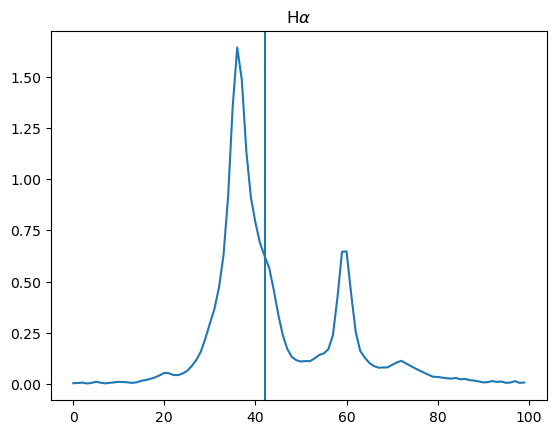

In [9]:
mask_HA = (wavelenghts > 6714)*(wavelenghts < 6724)
image_HA = image_cut[:, mask_HA]
#image_HA = image_cut[6719]#cut su 6719 A
radial_profile_HA = np.mean(image_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.axvline(42)

The fit gives us these parameters: A = 1.95, A2 = 0.75, mu = 36.29, mu2 = 59.54


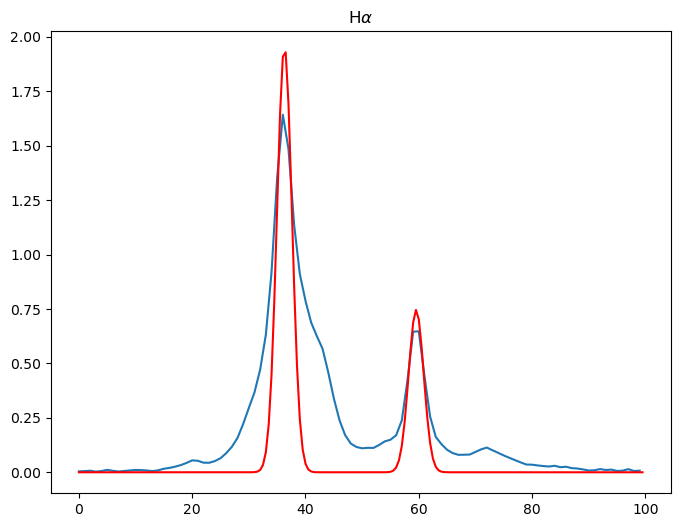

In [10]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2):
    gauss1 = A*np.exp(-(x-mu)**2/(2*sigma**2))
    gauss2 = A2*np.exp(-(x-mu2)**2/(2*sigma**2))
    return gauss1+gauss2
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60])
A, A2, mu, mu2 = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f' % (A, A2, mu, mu2))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5)

plt.show()

C:\Users\ISAFA\anaconda3\Lib\site-packages\astropy\modeling\functional_models.py:858: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
C:\Users\ISAFA\anaconda3\Lib\site-packages\astropy\modeling\functional_models.py:858: RuntimeWarning: divide by zero encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)


The fit gives us these parameters: A = 1.71, A2 = 0.53, mu = 36.29, mu2 = 59.56, As = 0.16, r_eff = 51.50, n = 0.11


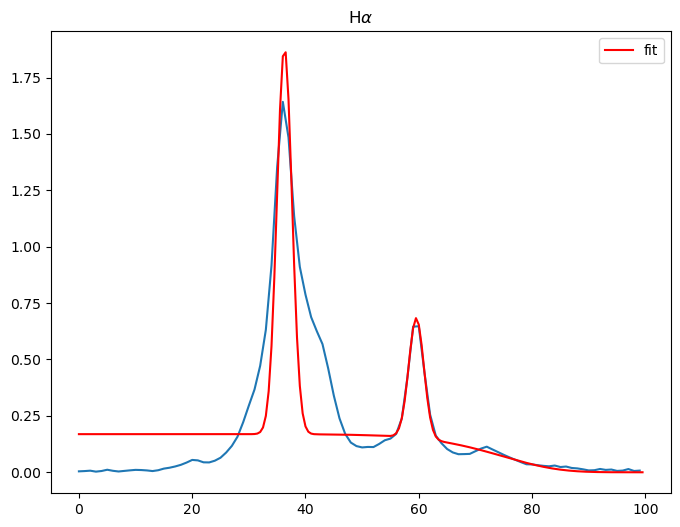

In [11]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()

plt.show()

In [12]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03):
    return sersic_1d(x, I_e1, r_e1, n1, x_01)+sersic_1d(x, I_e2, r_e2, n2, x_02)+sersic_1d(x, I_e3, r_e3, n3, x_03)

bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1e-2, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, np.inf, 55] )
print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[1, 1, 0.5, 38, 1e-3, 1, 0.5, 58.5, 1e-3, 50, 0.5, 50], method ='trf', bounds = bounds)
I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, x01 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, x02 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, x03 = %.2f ' % (I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, x_01), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, x_02), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, x_03), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [0.01, 10, 0.7, 45, 0.001, 30, 0.7, 65, 0.001, inf, 55])


ValueError: operands could not be broadcast together with shapes (12,) (11,) 

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4):
    return sersic_1d(x, I_e1, r_e1, n1, 36.25)+sersic_1d(x, I_e2, r_e2, n2, 59.50)+sersic_1d(x, I_e3, r_e3, n3, 42.58)+sersic_1d(x, I_e4, r_e4, n4, 72)

#bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, 100, 0.7, 55] )
#print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[1, 1, 0.5, 1e-3, 1, 0.5, 1e-3, 50, 0.5, 1e-3, 1, 0.5]) #method ='trf', bounds = bounds)
I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, Ie4 = %.4f, r_eff_4 = %.2f, n4 = %.2f ' % (I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4) )
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, 36.25), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, 59.50), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, 42.58), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e4, r_e4, n4, 72), color = 'orange', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

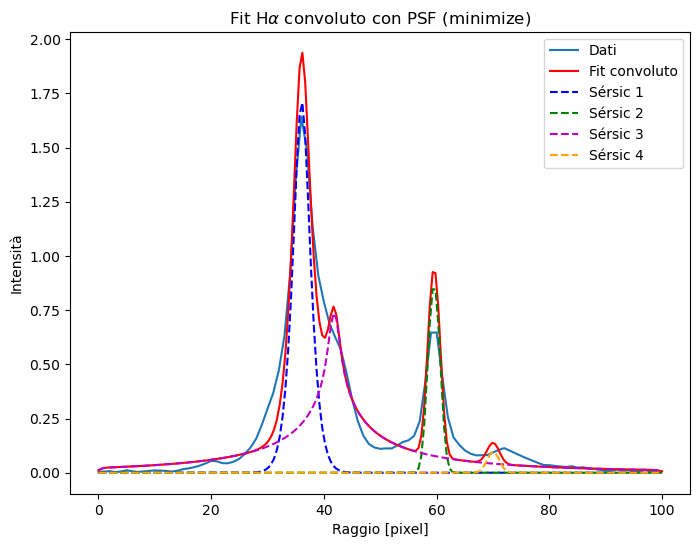

Parametri ottimizzati:
 [6.42102872e-01 2.10340711e+00 7.43508508e-01 3.60463594e+01
 7.00557277e-01 9.22319162e-01 3.25558806e-01 5.95276398e+01
 1.62529353e-02 4.99771643e+01 2.35153765e+00 4.18042313e+01
 6.54088257e-02 9.83166583e-01 4.50684277e-01 7.00197260e+01]


(-0.2, 0.2)

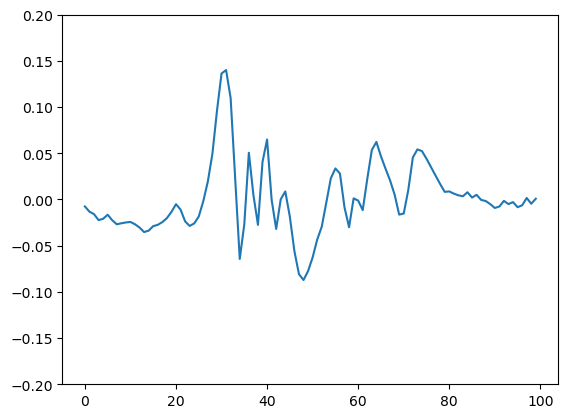

In [44]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n): #Evaluate B_n for the sersic profile 
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0): #Sersic profile centered in x0
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

#def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
#    profile = sersic_1d(x, I_e, r_e, n, x_0)
#    kernel = Gaussian1DKernel(stddev=sigma, x_size=len(x), mode='center')   #The PSF is a gaussian centered in 0!
#    conv_profile = convolve(profile, kernel, mode='same')
#    return conv_profile

def model_convolved(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04):
    return (sersic_1d_convolved(x, I_e1, r_e1, n1, x_01) +
        sersic_1d_convolved(x, I_e2, r_e2, n2, x_02) +
        sersic_1d_convolved(x, I_e3, r_e3, n3, x_03) +
        sersic_1d_convolved(x, I_e4, r_e4, n4, x_04))

def chi_squared(params, x, y_obs):
    I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04 = params
    y_model = model_convolved(x, I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04)
    return np.sum((y_obs - y_model)**2)
    
initial_guess = [1, 1, 0.5, 36, 1e-3, 1, 0.5, 60,  1e-3, 50, 0.5, 42, 1e-3, 1, 0.5, 70]  

result = minimize(
    chi_squared,
    x0=initial_guess,
    args=(x_axes, radial_profile_HA),
    method='L-BFGS-B',
    options={'maxiter': 10000, 'disp': True}
)    

xgrid = np.arange(0, 100, 0.5)
    
best_params = result.x
xgrid = np.linspace(0, 100, 200)
y_fit = model_convolved(xgrid, *best_params)
y_fit_data = model_convolved(x_axes, *best_params)

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), 'orange', linestyle='--', label='Sérsic 4')

plt.xlabel("Raggio [pixel]")
plt.ylabel("Intensità")
plt.title(r"Fit H$\alpha$ convoluto con PSF (minimize)")
plt.legend()
plt.show()
print("Parametri ottimizzati:\n", best_params)

plt.plot(x_axes, radial_profile_HA - y_fit_data)
plt.ylim(-0.2, 0.2)

100

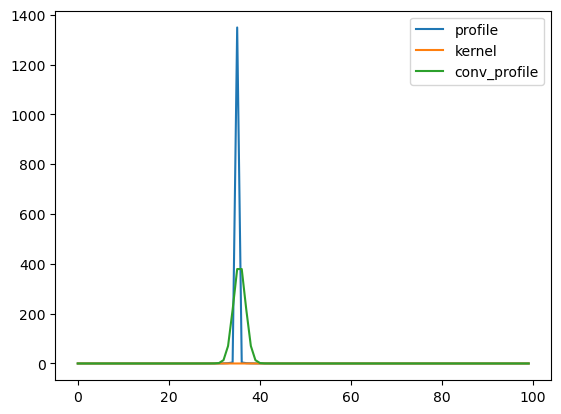

In [38]:
profile_low = sersic_1d(x_axes, 0.63, 3, 4, 35)
kernel_low = Gaussian1DKernel(stddev=sigma, x_size=len(x_axes), mode='center')   #The PSF is a gaussian centered in 0!
conv_profile_low = convolve(profile_low, kernel_low, mode='same')

plt.plot(x_axes, profile_low, label = 'profile')
plt.plot(x_axes, kernel_low, label = 'kernel')
plt.plot(x_axes, conv_profile_low, label = 'conv_profile')
plt.legend()
len(x_axes)

13.297872340425531
1.3297872340425532
1000
100


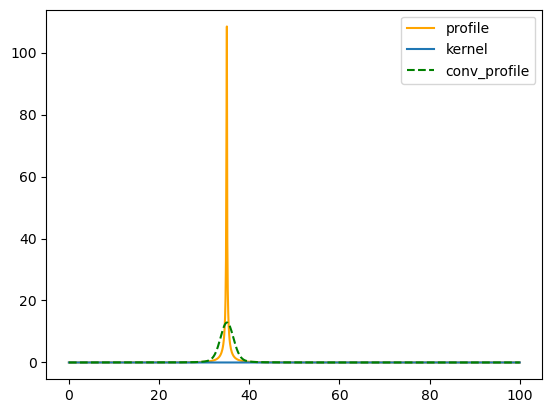

In [39]:
sigma = 3.125/2.35
x_grid = np.linspace(0, 100, 1000)

sigma1 = sigma *(len(x_grid) / len(x_axes))

print(sigma1)
print(sigma)
print(len(x_grid))
print(len(x_axes))

profile = sersic_1d(x_grid, 0.63, 3, 4, 35)
kernel = Gaussian1DKernel(stddev=sigma1, x_size=len(x_grid), mode='center')   #The PSF is a gaussian centered in 0!
conv_profile = convolve(profile, kernel, mode='same')

plt.plot(x_grid, profile, label = 'profile', color = 'orange')
plt.plot(x_grid, kernel, label = 'kernel')
plt.plot(x_grid, conv_profile, '--', label = 'conv_profile', color = 'green')
plt.legend()



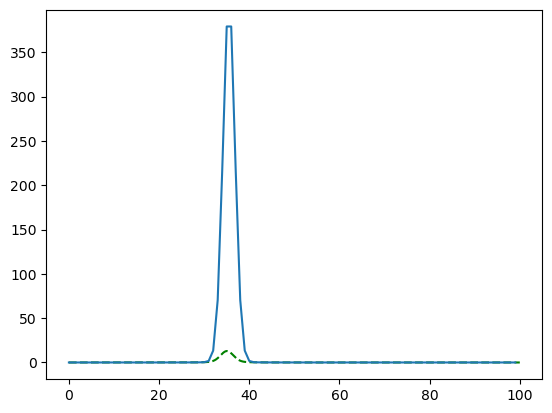

In [40]:
plt.plot(x_grid, conv_profile, '--', label = 'conv_profile', color = 'green')
plt.plot(x_axes, conv_profile_low, label = 'conv_profile')

## H$\beta$

In [ ]:
mask_HB = (wavelenghts > 4967)*(wavelenghts < 4987)
image_HB = image_cut[:, mask_HB] #cut su 4977 A
radial_profile_HB = np.mean(image_HB, axis = 1)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def calculate_bn(n):
    """
    Calcola il parametro b_n per il profilo di Sérsic.
    Approssimazione valida per 0.5 < n < 10.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)
    
def sersic_1d(x, I_e, r_e, n, x_0):
    # x_0 è il centro del profilo come parametro libero
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def model(x, I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4):
    return sersic_1d(x, I_e1, r_e1, n1, 36.25)+sersic_1d(x, I_e2, r_e2, n2, 59.50)+sersic_1d(x, I_e3, r_e3, n3, 42.58)+sersic_1d(x, I_e4, r_e4, n4, 72)

#bounds = ([0, 0, 0, 35, 0, 0, 0, 55, 0, 0, 0, 45], [1, 10, 0.7, 45, 1e-3, 30, 0.7, 65, 1e-3, 100, 0.7, 55] )
#print(bounds)

params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[1, 1, 0.5, 1e-3, 1, 0.5, 1e-3, 50, 0.5, 1e-3, 1, 0.5]) #method ='trf', bounds = bounds)
I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4 = params
print(r'The fit gives us these parameters: Ie1 = %.2f, re1 = %.2f, n1 = %.2f, Ie2 = %.4f, r_eff_2 = %.2f, n2 = %.2f, Ie3 = %.4f, r_eff_3 = %.2f, n3 = %.2f, Ie4 = %.4f, r_eff_4 = %.2f, n4 = %.2f ' % (I_e1, r_e1, n1, I_e2, r_e2, n2, I_e3, r_e3, n3, I_e4, r_e4, n4) )
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.plot(xgrid, sersic_1d(xgrid, I_e1, r_e1, n1, 36.25), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e2, r_e2, n2, 59.50), color = 'blue', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e3, r_e3, n3, 42.58), color = 'green', lw = 1.5, label ='fit', linestyle= '--')
plt.plot(xgrid, sersic_1d(xgrid, I_e4, r_e4, n4, 72), color = 'orange', lw = 1.5, label ='fit', linestyle= '--')
plt.legend()

plt.show()

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[0.25, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [NII]

In [ ]:
mask_NII = (wavelenghts > 6694)*(wavelenghts < 6714)
image_NII = image_cut[:, mask_NII] #cut su 6704 A
radial_profile_NII = np.mean(image_NII, axis = 1)
plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_NII, p0=[0.15, 0.2, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [SII]

In [ ]:
mask_SII = (wavelenghts > 6867)*(wavelenghts < 6887)
image_SII = image_cut[:, mask_SII] #cut su 6877 A
radial_profile_SII = np.mean(image_SII, axis = 1)
plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.125, 0.175, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [OIII]

In [ ]:
mask_OIII = (wavelenghts > 5067)*(wavelenghts < 5087)
image_OIII = image_cut[:, mask_OIII] #cut su 5077 A
radial_profile_OIII = np.mean(image_OIII, axis = 1)
plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')

In [ ]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_OIII, p0=[0.15, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()